# Pension reform — public event-detection notebook (anonymized data)

This notebook reproduces the article-aligned pipeline on **`PensionReform.csv`** (precomputed `likert_scale_Q1`, 1–5). **Sections:** EDA → $\Delta$MEC stability → parameter grids (sentiment, volume, MEC) → final configurations → evaluation vs sentiment baseline → main figure.

**Requirements:** Python 3.10+ and the `measures` package providing `MECNormalized` (see README).


## Likert schema

- Map **`likert_scale_Q1`** → **`Classification`** (English labels: *Strongly Disagree* … *Strongly Agree*).
- **`orden_likert`**, **`likert_weights`** $(0.0,\ldots,1.0)$, **`likert_class_map`**: same role as the exploratory notebook; analysis uses **`agg_per_author=False`** (comment-level distributions).


In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import anderson, norm, normaltest, poisson, probplot, shapiro

from measures.metrics.proposed.mec import MECNormalized

LIKERT_Q1_TO_CLASSIFICATION = {
    1: "Strongly Disagree",
    2: "Disagree",
    3: "Neutral",
    4: "Agree",
    5: "Strongly Agree",
}

orden_likert = [
    "Strongly Disagree",
    "Disagree",
    "Neutral",
    "Agree",
    "Strongly Agree",
]

likert_weights = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
likert_class_map = dict(zip(likert_weights, orden_likert))

mec_normalized = MECNormalized(alpha=2.0, beta=1.15)
plt.style.use("seaborn-v0_8-whitegrid")


## Load data

Path: `data/PensionReform.csv` (this notebook lives in `notebooks/`).


In [33]:
def _find_article_files_root() -> Path:
    """Resolve `article-files/` (contains data/PensionReform.csv). Prefer the bundle under
    event-detection/article-files/ when the monorepo also has another top-level data/ folder."""
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        nested = base / "event-detection" / "article-files" / "data" / "PensionReform.csv"
        if nested.is_file():
            return base / "event-detection" / "article-files"
    for base in [start, *start.parents]:
        if (base / "data" / "PensionReform.csv").is_file():
            return base
    raise FileNotFoundError(
        "Could not find data/PensionReform.csv; cd to article-files/ or notebooks/, "
        "or open the project root that contains event-detection/article-files/."
    )


REPO_ROOT = _find_article_files_root()
DATA_PATH = REPO_ROOT / "data" / "PensionReform.csv"

df = pd.read_csv(DATA_PATH)
df = df.drop_duplicates(subset="id").sort_values(by="id").reset_index(drop=True)

bad = df["likert_scale_Q1"].dropna()
bad = bad[(bad < 1) | (bad > 5) | (bad % 1 != 0)]
if len(bad):
    raise ValueError(f"likert_scale_Q1 must be integers 1–5; invalid rows: {len(bad)}")

df["Classification"] = df["likert_scale_Q1"].astype(int).map(LIKERT_Q1_TO_CLASSIFICATION)
if df["Classification"].isna().any():
    raise ValueError("Unmapped likert_scale_Q1 values present.")

df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
df["date"] = df["created_at"].dt.date

print(df.shape)
print(df["date"].min(), "→", df["date"].max())
df.groupby("Classification", observed=False).size().reindex(orden_likert).fillna(0).astype(int)


(9997, 7)
2024-06-22 → 2024-07-19


Classification
Strongly Disagree    3742
Disagree              389
Neutral              1448
Agree                 549
Strongly Agree       3869
dtype: int32

## Core helpers

Rolling daily summaries, moving-window detection with Poisson / normal tails, IQR-based $\Delta$MEC detection, and plotting utilities.


In [34]:
def get_polarization_level(polarization_function, opinion_distribution, x_weights):
    if opinion_distribution.sum() == 0:
        return 0
    return polarization_function(x_weights, opinion_distribution)


def get_mean_opinion(opinion_distribution, x_weights):
    if opinion_distribution.sum() == 0:
        return 0
    opinion_distribution_weighted = opinion_distribution * x_weights
    return opinion_distribution_weighted.sum() / opinion_distribution.sum()


def get_median_opinion(opinion_distribution, x_weights):
    if opinion_distribution.sum() == 0:
        return 0
    total = opinion_distribution.sum()
    cumsum = 0
    for count, weight in zip(opinion_distribution, x_weights):
        cumsum += count
        if cumsum >= total / 2:
            return weight
    return x_weights[-1]


def extract_opinion_distribution(df, agg_per_author=False, agg_author_per="all", n=1):
    if agg_per_author:
        if agg_author_per == "all":
            author_df = df.groupby("author_id").agg({
                "Classification": lambda tweets: likert_class_map[get_median_opinion(
                    opinion_distribution=pd.Series(tweets).value_counts().reindex(orden_likert).fillna(0),
                    x_weights=likert_weights,
                )]
            })
        elif agg_author_per == "last_n_tweets":
            last_n_tweets = df.sort_values("created_at").groupby("author_id").tail(n)
            author_df = last_n_tweets.groupby("author_id").agg({
                "Classification": lambda tweets: likert_class_map[get_median_opinion(
                    opinion_distribution=pd.Series(tweets).value_counts().reindex(orden_likert).fillna(0),
                    x_weights=likert_weights,
                )]
            })
        elif agg_author_per == "last_n_days":
            df_sorted = df.sort_values("date").copy()
            df_sorted["max_date"] = df_sorted.groupby("author_id")["date"].transform("max")
            tweets_last_n_days = df_sorted[df_sorted["date"] >= (df_sorted["max_date"] - pd.Timedelta(days=n - 1))].copy()
            tweets_last_n_days = tweets_last_n_days.drop(columns="max_date")
            author_df = tweets_last_n_days.groupby("author_id").agg({
                "Classification": lambda tweets: likert_class_map[get_median_opinion(
                    opinion_distribution=pd.Series(tweets).value_counts().reindex(orden_likert).fillna(0),
                    x_weights=likert_weights,
                )]
            })
        else:
            raise ValueError("agg_author_per must be all, last_n_tweets, or last_n_days")
        return author_df.groupby("Classification").size().reindex(orden_likert).fillna(0)
    return df.groupby("Classification").size().reindex(orden_likert).fillna(0)


def resumen_diario_con_ventana(
    df, window, orden_likert, agg_per_author=False, agg_author_per="last_n_days", n=1, metric=None
):
    dates = pd.date_range(df["date"].min(), df["date"].max())
    conteos_diarios = pd.DataFrame(
        0.0,
        index=dates,
        columns=list(orden_likert)
        + [
            "total_tweets",
            "total_individuals",
            "percentage_negative",
            "percentage_positive",
            "polarization",
            "mean_opinion",
            "median_opinion",
        ],
    )
    for date in dates:
        date_range = pd.date_range(end=date, periods=window).date
        window_tweets = df[df["date"].isin(date_range)]
        if len(window_tweets) == 0:
            continue
        opinion_dist = extract_opinion_distribution(
            window_tweets, agg_per_author=agg_per_author, agg_author_per=agg_author_per, n=n
        )
        conteos_diarios.loc[date, orden_likert] = opinion_dist.values.flatten()
        if metric is None:
            conteos_diarios.loc[date, "total_tweets"] = len(window_tweets)
            conteos_diarios.loc[date, "total_individuals"] = opinion_dist.sum()
            tot = conteos_diarios.loc[date, "total_individuals"]
            conteos_diarios.loc[date, "percentage_negative"] = opinion_dist.iloc[0:2].sum() / tot
            conteos_diarios.loc[date, "percentage_positive"] = opinion_dist.iloc[3:].sum() / tot
            conteos_diarios.loc[date, "polarization"] = get_polarization_level(
                mec_normalized, opinion_dist, likert_weights
            )
            conteos_diarios.loc[date, "mean_opinion"] = get_mean_opinion(opinion_dist, likert_weights)
            conteos_diarios.loc[date, "median_opinion"] = get_median_opinion(opinion_dist, likert_weights)
        else:
            if metric in ("total_individuals", "percentage_negative", "percentage_positive"):
                conteos_diarios.loc[date, "total_individuals"] = opinion_dist.sum()
            if metric == "total_tweets":
                conteos_diarios.loc[date, "total_tweets"] = len(window_tweets)
            elif metric == "percentage_negative":
                tot = opinion_dist.sum()
                conteos_diarios.loc[date, "percentage_negative"] = opinion_dist.iloc[0:2].sum() / tot
            elif metric == "percentage_positive":
                tot = opinion_dist.sum()
                conteos_diarios.loc[date, "percentage_positive"] = opinion_dist.iloc[3:].sum() / tot
            elif metric == "polarization":
                conteos_diarios.loc[date, "polarization"] = get_polarization_level(
                    mec_normalized, opinion_dist, likert_weights
                )
            elif metric == "mean_opinion":
                conteos_diarios.loc[date, "mean_opinion"] = get_mean_opinion(opinion_dist, likert_weights)
            elif metric == "median_opinion":
                conteos_diarios.loc[date, "median_opinion"] = get_median_opinion(opinion_dist, likert_weights)
    return conteos_diarios


def get_moving_window_key(window_size, agg_auth, agg_type, n):
    if window_size == 1 and agg_type == "last_n_days":
        n = 1
    return f"window={window_size}, agg_auth={agg_auth}, agg_type={agg_type}, n={n}"


def detect_events_moving_window(
    window_size,
    threshold,
    opinion_distribution_moving_window,
    metric,
    agg_per_author=False,
    agg_author_per="all",
    n=None,
):
    serie_key_daily = get_moving_window_key(window_size=1, agg_auth=agg_per_author, agg_type=agg_author_per, n=n)
    daily_freq = opinion_distribution_moving_window[serie_key_daily][metric]
    serie_key_window = get_moving_window_key(
        window_size=window_size, agg_auth=agg_per_author, agg_type=agg_author_per, n=n
    )
    if metric in ("total_tweets", "total_individuals"):
        moving_avg = opinion_distribution_moving_window[serie_key_window][metric] / window_size
    else:
        moving_avg = opinion_distribution_moving_window[serie_key_window][metric]
    moving_avg_shifted = moving_avg.shift(1)
    freq_ratios = daily_freq / moving_avg_shifted
    events_mask = freq_ratios >= threshold
    event_dates = daily_freq.index[events_mask]
    if metric in ("total_tweets", "total_individuals"):
        lambda_poisson = moving_avg_shifted.loc[event_dates]
        observed = daily_freq.loc[event_dates]
        p_values = 1 - poisson.cdf(observed - 1, lambda_poisson)
    else:
        rolling_std = daily_freq.rolling(window=window_size, min_periods=1).std()
        rolling_std_shifted = rolling_std.shift(1)
        std_at_events = rolling_std_shifted.loc[event_dates]
        moving_avg_at_events = moving_avg_shifted.loc[event_dates]
        observed = daily_freq.loc[event_dates]
        z_scores = (observed - moving_avg_at_events) / std_at_events
        p_values = 1 - norm.cdf(z_scores)

    def get_significance_mark(p_value):
        if p_value < 0.001:
            return "***"
        if p_value < 0.01:
            return "**"
        if p_value < 0.05:
            return "*"
        return ""

    return pd.DataFrame(
        {
            "date": event_dates,
            "ratio": freq_ratios.loc[event_dates],
            "p_value": p_values,
            "significance": [get_significance_mark(p) for p in p_values],
        },
        index=event_dates,
    ).reset_index(drop=True)


def detect_events_polarization_1st_diff(
    opinion_distribution_moving_window, window_size, lambda_fix=0.2, agg_per_author=False, agg_author_per="all", n=None
):
    serie_key_window = get_moving_window_key(
        window_size=window_size, agg_auth=agg_per_author, agg_type=agg_author_per, n=n
    )
    polarization_1st_differencing = opinion_distribution_moving_window[serie_key_window]["1st_diff_polarization"]
    q25 = polarization_1st_differencing.quantile(0.25)
    q75 = polarization_1st_differencing.quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - lambda_fix * iqr
    upper_bound = q75 + lambda_fix * iqr
    event_mask = (polarization_1st_differencing < lower_bound) | (polarization_1st_differencing > upper_bound)
    event_dates = polarization_1st_differencing.index[event_mask]
    observed = polarization_1st_differencing.loc[event_dates]
    mean_diff = polarization_1st_differencing.mean()
    std_diff = polarization_1st_differencing.std()
    z_scores = (observed - mean_diff) / std_diff
    p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))

    def get_significance_mark(p_value):
        if p_value < 0.001:
            return "***"
        if p_value < 0.01:
            return "**"
        if p_value < 0.05:
            return "*"
        return ""

    return pd.DataFrame(
        {
            "date": event_dates,
            "1st_diff_polarization": observed.values,
            "z_score": z_scores.values,
            "p_value": p_values,
            "significance": [get_significance_mark(p) for p in p_values],
        }
    ).reset_index(drop=True)


def plot_ratio_series(
    serie_df, metrics, colors, labels, ax, thresholds=None, thresholds_labels=None,
    add_legend=False, show_x_ticks=True, show_y_ticks=True, left_margin=0.1,
):
    plt.subplots_adjust(left=left_margin)
    if thresholds is not None:
        cmap = plt.cm.RdBu_r
        n_regions = len(thresholds) + 1
        colors_regions = cmap(np.linspace(0, 1, n_regions))
        ax.axhspan(0, thresholds[0], color=colors_regions[0], alpha=0.3)
        for i in range(len(thresholds) - 1):
            ax.axhspan(thresholds[i], thresholds[i + 1], color=colors_regions[i + 1], alpha=0.3)
        ax.axhspan(thresholds[-1], 1, color=colors_regions[-1], alpha=0.3)
    for metric, color, label in zip(metrics, colors, labels):
        alpha = 0.6 if metric == "polarization" else 0.2
        ax.plot(np.arange(len(serie_df)), serie_df[metric].values, color=color, alpha=alpha, label=label)
    ax.set_xticks(range(len(serie_df.index)))
    if show_x_ticks:
        ax.set_xticklabels([d for d in serie_df.index.strftime("%Y-%m-%d")], rotation=60, ha="right")
    else:
        ax.set_xticklabels([])
    ax.set_ylabel("index (0 to 1)")
    if show_y_ticks and thresholds is not None and thresholds_labels is not None:
        ax2 = ax.twinx()
        ticks = []
        ki = 0
        for k in thresholds:
            tick = (ki + k) / 2
            ticks.append(tick)
            ki = k
        ticks.append((1 + ki) / 2)
        ax2.set_ylim(0, 1)
        ax2.set_yticks(ticks)
        ax2.set_yticklabels(thresholds_labels)
        ax2.grid(False)
    elif not show_y_ticks:
        ax.set_yticks([])
        ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    if add_legend:
        ax.legend(bbox_to_anchor=(0.5, -0.2), loc="upper center", ncol=3, frameon=True)


def plot_bars_serie(serie_df, feature, date_info, feature_label="", title="", ax=None, show_x_ticks=True, show_y_ticks=True):
    plt.style.use("seaborn-v0_8-whitegrid")
    sdf = serie_df.merge(date_info, left_index=True, right_on="date", how="left").set_index("date")
    if ax is None:
        ax = plt.gca()
    sdf = sdf.copy()
    sdf["fecha"] = sdf.index
    sdf.plot(kind="bar", x="fecha", y=feature, alpha=0.7, width=0.7, ax=ax, legend=False)
    ax.set_title(title if title else f"Daily count: {feature_label}")
    ax.set_xlabel("")
    if show_x_ticks:
        ax.set_xticks(range(len(sdf.index)))
        ax.set_xticklabels([d for d in sdf.index.strftime("%Y-%m-%d")], rotation=60, ha="right")
    else:
        ax.set_xticks(range(len(sdf.index)))
        ax.set_xticklabels([])
    if show_y_ticks:
        ax.set_ylabel(feature_label)
    else:
        ax.set_yticks([])
        ax.set_yticklabels([])
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", linestyle="--", alpha=0.5)


def plot_opinion_distribution_serie(
    serie_df, orden_likert, date_info, ax=None, show_x_ticks=True, show_y_ticks=True, add_legend=False
):
    plt.style.use("seaborn-v0_8-whitegrid")
    if ax is None:
        ax = plt.gca()
    sdf = serie_df.merge(date_info, left_index=True, right_on="date", how="left").set_index("date")
    colors = plt.cm.PiYG(np.linspace(0, 1, len(orden_likert)))
    df_likert = sdf[orden_likert]
    df_sum = df_likert.sum(axis=1)
    df_likert_rel = df_likert.div(df_sum, axis=0)
    df_likert_rel.plot(kind="bar", stacked=True, color=colors, alpha=0.6, width=0.7, ax=ax)
    ax.axhline(y=0.5, color="gray", linewidth=1.5)
    if show_x_ticks:
        ax.set_xticks(range(len(sdf.index)))
        ax.set_xticklabels([d for d in sdf.index.strftime("%Y-%m-%d")], rotation=60, ha="right")
    else:
        ax.set_xticks(range(len(sdf.index)))
        ax.set_xticklabels([])
    if show_y_ticks:
        ax.set_ylabel("Relative frequency of stance")
    else:
        ax.set_yticks([])
        ax.set_yticklabels([])
    if add_legend:
        ax.legend(title="Stance (Likert)", bbox_to_anchor=(0.5, -0.35), loc="center", ncol=3, frameon=True)
    else:
        ax.legend().remove()
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", linestyle="--", alpha=0.5)


def plot_opinion_ratio_series(
    serie_df, orden_likert, mean_feature="mean_opinion", median_feature="median_opinion",
    add_legend=False, ax=None, show_x_ticks=True, show_y_ticks=True,
):
    plt.style.use("seaborn-v0_8-whitegrid")
    if ax is None:
        ax = plt.gca()
    colors = plt.cm.PiYG(np.linspace(0, 1, len(orden_likert)))

    def band_color(val):
        if val < 0.2:
            return colors[0]
        if val < 0.4:
            return colors[1]
        if val < 0.6:
            return colors[2]
        if val < 0.8:
            return colors[3]
        return colors[4]

    for start, end, val in [(0, 0.2, 0), (0.2, 0.4, 0.25), (0.4, 0.6, 0.45), (0.6, 0.8, 0.65), (0.8, 1.0, 0.85)]:
        ax.axhspan(start, end, color=band_color(val), alpha=0.3)
    line_color = sns.husl_palette()[2]
    x = np.arange(len(serie_df))
    ax.plot(x, serie_df[mean_feature].values, color=line_color)
    ax.plot(x, serie_df[median_feature].values, linestyle="--", alpha=0.4, color=line_color)
    ax.set_xlabel("")
    if show_x_ticks:
        ax.set_xticks(x)
        ax.set_xticklabels([d for d in serie_df.index.strftime("%Y-%m-%d")], rotation=60, ha="right")
    else:
        ax.set_xticks(x)
        ax.set_xticklabels([])
    if show_y_ticks:
        ax2 = ax.twinx()
        ax2.set_ylim(ax.get_ylim())
        ax2.set_yticks([0.1, 0.3, 0.5, 0.7, 0.9])
        ax2.set_yticklabels(orden_likert)
        ax2.grid(False)
    else:
        ax.set_yticks([])
        ax.set_yticklabels([])
    handles = [
        plt.Line2D([0], [0], color=line_color, alpha=0.4, linestyle="--", linewidth=1.5),
        plt.Line2D([0], [0], color=line_color, linewidth=1.5),
    ]
    labels = ["Median stance", "Mean stance"]
    if add_legend:
        ax.legend(handles, labels, bbox_to_anchor=(0.5, -0.2), loc="upper center", ncol=2, frameon=True)
    ax.set_ylim(-0.01, 1.01)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", linestyle="--", alpha=0.5)


def load_polarization_thermometer_assets(fig_dir):
    # Load termometers.png and escalas_polarizacion.png from fig_dir (e.g. article-files/figures).
    from PIL import Image

    termometers_path = fig_dir / "termometers.png"
    scales_path = fig_dir / "escalas_polarizacion.png"
    if not termometers_path.is_file():
        raise FileNotFoundError(
            f"Missing {termometers_path.name}. Copy it into {fig_dir} (same assets as event-detection/)."
        )
    if not scales_path.is_file():
        raise FileNotFoundError(
            f"Missing {scales_path.name}. Copy it into {fig_dir} (same assets as event-detection/)."
        )
    original_image = Image.open(termometers_path)
    scales_image = Image.open(scales_path)
    width, height = original_image.size
    start_x = 16
    termometer_width = (width - 2 * start_x) // 5
    termometers = [
        original_image.crop(
            (start_x + i * termometer_width, 20, start_x + (i + 1) * termometer_width, height - 40)
        )
        for i in range(5)
    ]
    return termometers, scales_image


def select_termometer(value, termometers):
    # Thresholds aligned with exploratory notebook / MEC band plot.
    if value <= 0.1581:
        return termometers[0]
    if value <= 0.2141:
        return termometers[1]
    if value <= 0.2716:
        return termometers[2]
    if value <= 0.3503:
        return termometers[3]
    return termometers[4]


def plot_polarization_meter(temperature_value, termometers, scales_image, ax=None, title_prefix="Polarization (MEC)"):
    # Thermometer strip + polarization scale image (same layout as exploratory notebook).
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.add_subplot(111)
    selected = select_termometer(temperature_value, termometers)
    ax.axis("off")
    ax.set_title(f"{title_prefix}: {temperature_value:.2f}")
    ax_term = ax.inset_axes([0.2, 0.0, 0.6, 1.0])
    ax_term.imshow(selected)
    ax_term.axis("off")
    ax_scale = ax.inset_axes([0.1, -0.6, 0.8, 0.6])
    ax_scale.imshow(scales_image, aspect="auto")
    ax_scale.axis("off")
    return ax




def plot_polarization_1st_diff_analysis(series_df, lambda_val=0.2, title="", ax=None, left_margin=0.1):
    diff_series = series_df
    q25 = diff_series.quantile(0.25)
    q75 = diff_series.quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - lambda_val * iqr
    upper_bound = q75 + lambda_val * iqr
    if ax is None:
        _, ax = plt.subplots(figsize=(15, 6))
    plt.subplots_adjust(left=left_margin)
    all_dates = diff_series.index.strftime("%Y-%m-%d")
    x_positions = np.arange(len(all_dates))
    ax.axhspan(q25, q75, color="#019449", alpha=0.2, label="Interquartile Range (Q25 - Q75)")
    ax.axhspan(lower_bound, upper_bound, color="#f9b13a", alpha=0.2, label=f"±{lambda_val} IQR")
    ax.axhline(y=0, color="#24aae3", linewidth=1.5)
    bar_width = 0.1
    ax.bar(x_positions, diff_series.values, alpha=0.7, color="#24aae3", width=bar_width)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(all_dates, rotation=60, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel("First-Order Difference")
    ax.set_title(title)
    ax.grid(axis="both", linestyle="--", alpha=0.5)
    ax.set_ylim(-0.5, 0.58)
    ax.legend(bbox_to_anchor=(0.5, -0.35), loc="upper center", ncol=2, frameon=True)


def plot_detected_events(
    series_df,
    list_detected_events,
    window_size,
    feature_label,
    title=None,
    y_label=None,
    add_legend=False,
    ax=None,
    left_margin=0.1,
    ruptures=False,
    is_iqr=False,
    show_xticks=True,
):
    plt.style.use("seaborn-v0_8-whitegrid")
    husl = sns.color_palette("viridis", 3)
    label_color, event_color, event_line_color = husl[1], husl[2], husl[0]
    if isinstance(series_df, pd.DataFrame):
        series_colors = sns.color_palette("husl", len(series_df.columns))
    if ax is None:
        _, ax = plt.subplots(figsize=(15, 3))
        plt.subplots_adjust(left=left_margin)
    ax.grid(True, linestyle="--", alpha=0.5)
    legend_elements = []
    all_dates = series_df.index.strftime("%Y-%m-%d")
    x_positions = np.arange(len(all_dates))
    x_dates_dict = dict(zip(all_dates, x_positions))
    if isinstance(series_df, pd.DataFrame):
        for idx, column in enumerate(series_df.columns):
            line = ax.plot(
                x_positions,
                series_df[column].values,
                color=series_colors[idx],
                linewidth=1.5,
                label=column,
                alpha=0.5,
            )[0]
            legend_elements.append(line)
    else:
        line = ax.plot(x_positions, series_df.values, color=label_color, linewidth=1.5, label=feature_label)[0]
        legend_elements.append(line)
    last_event_idx = 0
    color_idx = 0
    if not isinstance(list_detected_events, list):
        list_detected_events = [list_detected_events]
    n0 = len(list_detected_events[0]) if len(list_detected_events) else 0
    husl_color_events = sns.color_palette("husl", max(n0, 1))
    for i, detected_events in enumerate(list_detected_events):
        for event_date in detected_events:
            event_idx = series_df.index.get_loc(event_date)
            event_x = x_dates_dict[event_date.strftime("%Y-%m-%d")]
            if window_size is not None:
                start_idx = max(0, event_idx - window_size)
                start_date = series_df.index[start_idx]
                start_x = x_dates_dict[start_date.strftime("%Y-%m-%d")]
                ax.axvspan(start_x, event_x, color=event_color, alpha=0.2)
            elif ((not isinstance(series_df, pd.DataFrame)) and not is_iqr) or ruptures:
                start_idx = last_event_idx
                start_date = series_df.index[start_idx]
                start_x = x_dates_dict[start_date.strftime("%Y-%m-%d")]
                ax.axvspan(start_x, event_x, color=husl_color_events[color_idx % len(husl_color_events)], alpha=0.2)
                last_event_idx = event_idx
                color_idx += 1
            ax.axvline(x=event_x, color=event_line_color, linestyle="--", alpha=0.7, linewidth=1)
            if isinstance(series_df, pd.DataFrame):
                col_name = series_df.columns[i]
                val = series_df[col_name].values[event_idx]
                ax.plot(event_x, val, "ro", markersize=6, alpha=0.7)
            else:
                ax.plot(event_x, series_df.values[event_idx], "ro", markersize=6, alpha=0.7)
    if show_xticks:
        ax.set_xticks(x_positions)
        ax.set_xticklabels(all_dates, rotation=60, ha="right")
    else:
        ax.set_xticks(x_positions)
        ax.set_xticklabels([])
    if y_label:
        ax.set_ylabel(y_label)
    if title:
        ax.set_title(title)
    if add_legend:
        legend_elements.extend(
            [
                plt.Rectangle((0, 0), 1, 1, color=event_color, alpha=0.2, label="Baseline Period"),
                plt.Line2D(
                    [0],
                    [0],
                    color=event_line_color,
                    linestyle="--",
                    marker="o",
                    markerfacecolor="red",
                    markersize=6,
                    alpha=0.7,
                    label="Detected Event",
                ),
            ]
        )
        ax.legend(handles=legend_elements, loc="center", bbox_to_anchor=(0.5, -0.5), ncol=3, frameon=True)
    ax.set_ylim(0, 1)
    return ax


def _ts(d):
    return pd.Timestamp(d).normalize()


def calculate_precision(detected_events, df_eventos, tolerance=0):
    event_dates = [_ts(x) for x in df_eventos["date"]]
    correct = 0
    for detection_date in detected_events:
        dd = _ts(detection_date)
        if any(
            dd == ev
            or dd + pd.Timedelta(days=tolerance) == ev
            or dd == ev + pd.Timedelta(days=tolerance)
            for ev in event_dates
        ):
            correct += 1
    return correct / len(detected_events) if len(detected_events) > 0 else 0.0


def calculate_recall(detected_events, df_eventos, tolerance=0):
    det = [_ts(x) for x in detected_events]
    detected_count = 0
    for _, event_row in df_eventos.iterrows():
        ev = _ts(event_row["date"])
        if any(
            d == ev
            or d + pd.Timedelta(days=tolerance) == ev
            or d == ev + pd.Timedelta(days=tolerance)
            for d in det
        ):
            detected_count += 1
    return detected_count / len(df_eventos) if len(df_eventos) else 0.0


def calculate_f1_score(detected_events, df_eventos, tolerance=0):
    p = calculate_precision(detected_events, df_eventos, tolerance)
    r = calculate_recall(detected_events, df_eventos, tolerance)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)


## Build rolling-window tables ($W \in \{1,2,3,5\}$, comment-level only)

Materialize **`opinion_distribution_moving_window`** for **`agg_per_author=False`**, then add **`1st_diff_polarization`**.


In [35]:
window_lengths = [1, 2, 3, 5]
opinion_distribution_moving_window = {}
for window_size in window_lengths:
    key = get_moving_window_key(window_size=window_size, agg_auth=False, agg_type="all", n=None)
    opinion_distribution_moving_window[key] = resumen_diario_con_ventana(
        df, window_size, orden_likert, agg_per_author=False
    )

for serie_df in opinion_distribution_moving_window.values():
    serie_df["1st_diff_polarization"] = serie_df["polarization"].diff().fillna(0)
    serie_df["abs_1st_diff_polarization"] = serie_df["1st_diff_polarization"].abs()

serie_key_daily = get_moving_window_key(1, False, "all", None)
daily = opinion_distribution_moving_window[serie_key_daily]
daily.head(3)

date_info = pd.DataFrame({"date": daily.index})
date_info["date"] = pd.to_datetime(date_info["date"])


## Exploratory figures

**Posting intensity (violins).** Most users contribute few posts overall and per calendar day, so aggregating stance **per comment** (instead of one stance per author per day) is unlikely to distort the daily opinion mix.

**Global stance and MEC.** Full-cohort stance counts and a **thermometer + scale** visualization for pooled MEC (same assets as the exploratory notebook: `figures/termometers.png`, `figures/escalas_polarizacion.png`).

**Daily panels.** (1) Post volume and stacked daily stance proportions ($W=1$ in `resumen`). (2) Daily sentiment signals (% negative / % positive) and MEC polarization on the same axes. (3) Daily mean vs median stance on the weighted 0–1 scale (optional context for the paper).


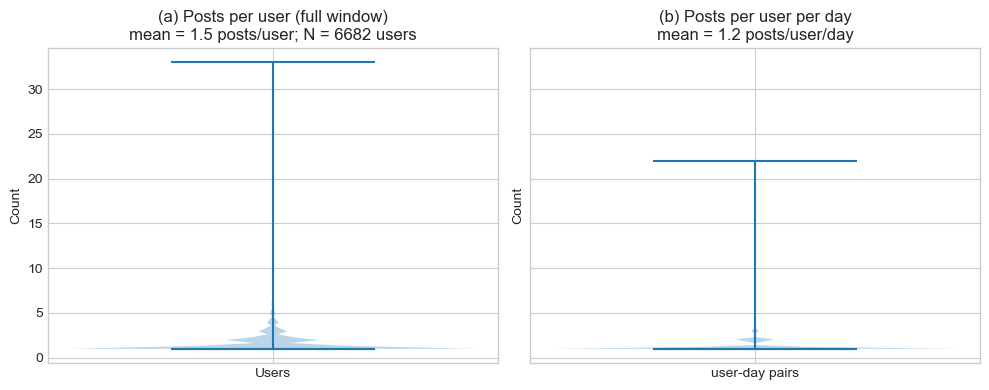

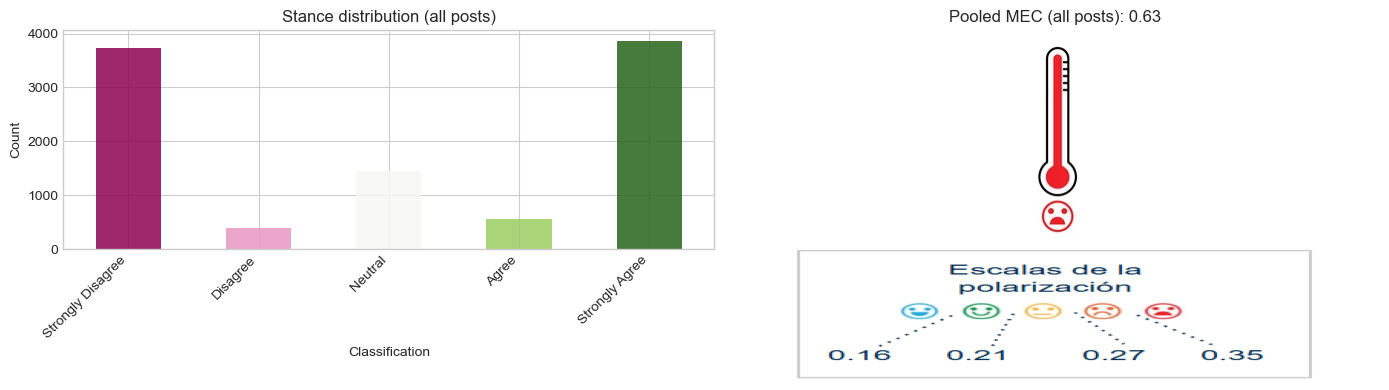

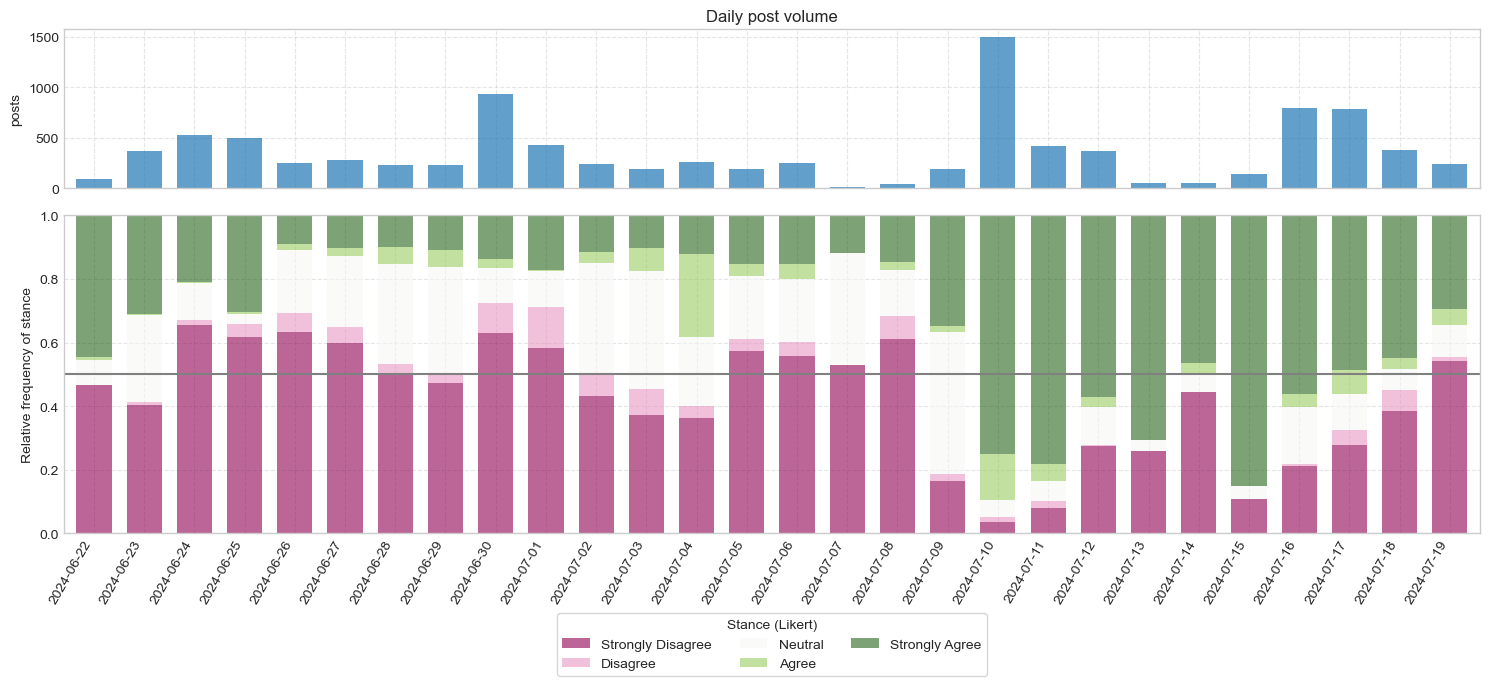

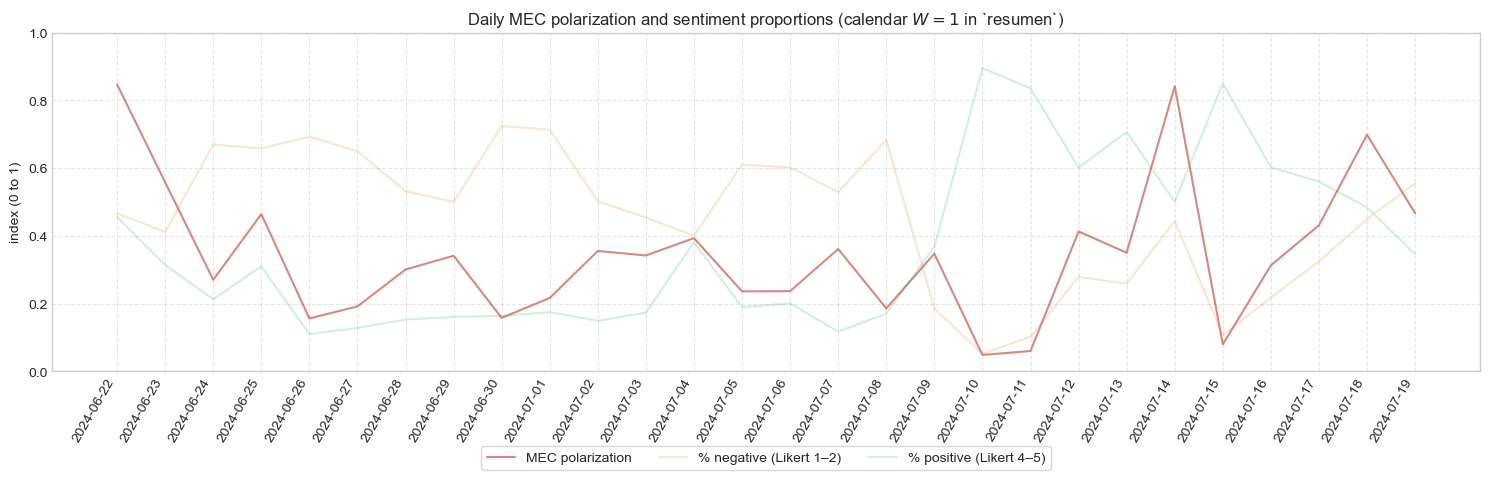

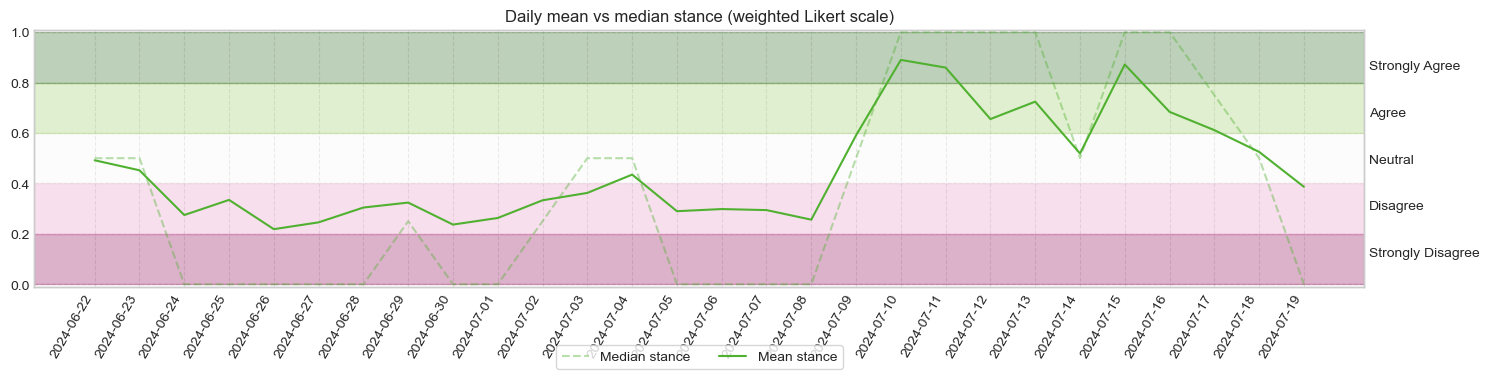

In [36]:
# Violin plots — justify comment-level stance aggregation
tweets_per_author = df.groupby("author_id").size().reset_index(name="n_tweets")
tweets_per_user_day = df.groupby(["date", "author_id"]).size().reset_index(name="n_tweets")
mu_author = tweets_per_author["n_tweets"].mean()
mu_day = tweets_per_user_day["n_tweets"].mean()

fig_v, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axs[0].violinplot(tweets_per_author["n_tweets"], showmedians=True)
axs[0].set_title(
    f"(a) Posts per user (full window)\nmean = {mu_author:.1f} posts/user; N = {len(tweets_per_author)} users"
)
axs[0].set_ylabel("Count")
axs[0].set_xticks([1])
axs[0].set_xticklabels(["Users"])

axs[1].violinplot(tweets_per_user_day["n_tweets"], showmedians=True)
axs[1].set_title(f"(b) Posts per user per day\nmean = {mu_day:.1f} posts/user/day")
axs[1].set_ylabel("Count")
axs[1].set_xticks([1])
axs[1].set_xticklabels(["user-day pairs"])
plt.tight_layout()
plt.show()

# Global stance (all comments) + MEC over the full pooled distribution
opinion_global = df.groupby("Classification").size().reindex(orden_likert).fillna(0)
fig_b, axb = plt.subplots(1, 2, figsize=(14, 5))
colors_bar = plt.cm.PiYG(np.linspace(0, 1, len(orden_likert)))
opinion_global.plot(kind="bar", ax=axb[0], color=colors_bar, alpha=0.85, legend=False)
axb[0].set_title("Stance distribution (all posts)")
axb[0].set_ylabel("Count")
axb[0].set_xticklabels(axb[0].get_xticklabels(), rotation=45, ha="right")

mec_global = get_polarization_level(mec_normalized, opinion_global.astype(float), likert_weights)
termometers, scales_image = load_polarization_thermometer_assets(REPO_ROOT / "figures")
plot_polarization_meter(
    mec_global,
    termometers,
    scales_image,
    ax=axb[1],
    title_prefix="Pooled MEC (all posts)",
)
plt.tight_layout()
plt.show()

# Daily volume + stacked stance proportions (same layout as original notebook)
fig1, (ax_top, ax_bot) = plt.subplots(
    nrows=2, ncols=1, figsize=(15, 7), gridspec_kw={"height_ratios": [1, 2]}
)
plot_bars_serie(
    daily,
    "total_tweets",
    date_info,
    feature_label="posts",
    title="Daily post volume",
    ax=ax_top,
    show_x_ticks=False,
    show_y_ticks=True,
)
plot_opinion_distribution_serie(
    daily, orden_likert, date_info, ax=ax_bot, show_x_ticks=True, add_legend=True
)
plt.tight_layout()
plt.show()

# Daily sentiment signals + MEC polarization (series that feed the detectors)
fig2, axm = plt.subplots(figsize=(15, 5))
plot_ratio_series(
    daily,
    metrics=["polarization", "percentage_negative", "percentage_positive"],
    colors=["#c0392b", "#e67e22", "#27ae60"],
    labels=["MEC polarization", "% negative (Likert 1–2)", "% positive (Likert 4–5)"],
    ax=axm,
    show_x_ticks=True,
    show_y_ticks=True,
    left_margin=0.1,
    add_legend=True,
)
axm.set_title("Daily MEC polarization and sentiment proportions (calendar $W=1$ in `resumen`)")
plt.tight_layout()
plt.show()

# Daily mean vs median stance (weighted 0–1 scale)
fig3, axo = plt.subplots(figsize=(15, 4))
plot_opinion_ratio_series(daily, orden_likert, ax=axo, add_legend=True, show_x_ticks=True)
axo.set_title("Daily mean vs median stance (weighted Likert scale)")
plt.tight_layout()
plt.show()


## $\Delta$MEC stability / normality ($W=2$ rolling polarization)

Uses **`1st_diff_polarization`** from **`window=2`** (same construction as the MEC detector).


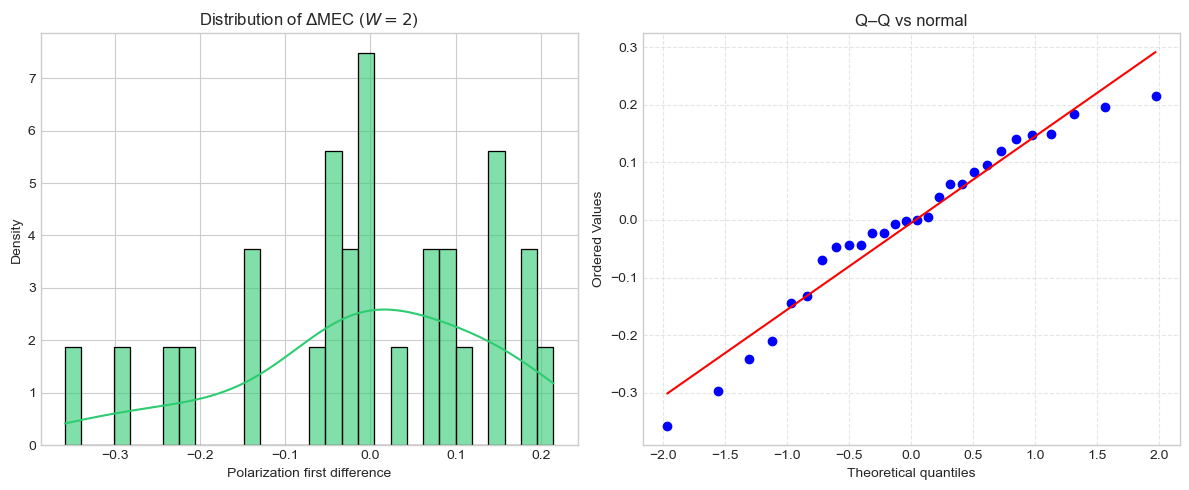

Shapiro–Wilk: W = 0.9506, p = 0.2052
D'Agostino–Pearson: stat = 2.6227, p = 0.2695
Anderson–Darling A² = 0.4394


In [37]:
serie_key_w2 = get_moving_window_key(2, False, "all", None)
delta_mec = opinion_distribution_moving_window[serie_key_w2]["1st_diff_polarization"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#2ecc71", "#3498db", "#e74c3c", "#f1c40f"]
sns.histplot(delta_mec, kde=True, ax=ax1, stat="density", bins=30, color=colors[0], alpha=0.6)
ax1.set_title(r"Distribution of $\Delta$MEC ($W=2$)")
ax1.set_xlabel("Polarization first difference")
probplot(delta_mec, dist="norm", plot=ax2)
ax2.set_title("Q–Q vs normal")
ax2.grid(True, alpha=0.5, linestyle="--")
plt.tight_layout()
plt.show()

sw_stat, sw_p = shapiro(delta_mec)
dp_stat, dp_p = normaltest(delta_mec)
ad = anderson(delta_mec)
print("Shapiro–Wilk: W =", f"{sw_stat:.4f}, p = {sw_p:.4g}")
print("D'Agostino–Pearson: stat =", f"{dp_stat:.4f}, p = {dp_p:.4g}")
print("Anderson–Darling A² =", f"{ad.statistic:.4f}")


## Sentiment baseline proxy (`df_eventos`)

$W=3$, $K=1.1$, union of **negative** and **positive** spike detectors, **p-value $< 0.05$** on each arm (local significance filter). This set is the **reference** for volume/MEC grids and for precision/recall.


In [38]:
P_CUT = 0.05
W0, K0 = 3, 1.1

neg_e = detect_events_moving_window(W0, K0, opinion_distribution_moving_window, "percentage_negative")
neg_e = neg_e[neg_e["p_value"] < P_CUT]
pos_e = detect_events_moving_window(W0, K0, opinion_distribution_moving_window, "percentage_positive")
pos_e = pos_e[pos_e["p_value"] < P_CUT]
neg_e = neg_e.copy()
pos_e = pos_e.copy()
neg_e["event_type"] = "negative"
pos_e["event_type"] = "positive"
df_eventos = pd.concat([neg_e, pos_e]).sort_values("date").reset_index(drop=True)
baseline_dates = pd.concat([neg_e["date"], pos_e["date"]]).drop_duplicates().sort_values()
print(len(df_eventos), "rows;", len(baseline_dates), "unique baseline dates")
print(baseline_dates.tolist())


12 rows; 12 unique baseline dates
[Timestamp('2024-06-24 00:00:00'), Timestamp('2024-06-30 00:00:00'), Timestamp('2024-07-04 00:00:00'), Timestamp('2024-07-05 00:00:00'), Timestamp('2024-07-08 00:00:00'), Timestamp('2024-07-09 00:00:00'), Timestamp('2024-07-10 00:00:00'), Timestamp('2024-07-12 00:00:00'), Timestamp('2024-07-14 00:00:00'), Timestamp('2024-07-15 00:00:00'), Timestamp('2024-07-18 00:00:00'), Timestamp('2024-07-19 00:00:00')]


## Parameter search — sentiment (maximize count after p-filter)

Grid: $W \in \{2,3,5\}$, $K \in [0, 5]$ step $0.1$. Objective: **maximize** the number of **distinct** days in the union of significant negative and positive detections. Tie-break: prefer **$W=3$, $K=1.1$** if among tied maxima; else highest $W$, then highest $K$.

This mirrors the manuscript: choose the configuration with the **largest** number of statistically filtered events; the article reports **12** unique days at **$W=3$, $K=1.1$**.


In [39]:
P_VAL = 0.05
W_opts = [2, 3, 5]
K_opts = [round(x, 1) for x in np.arange(0, 5.01, 0.1)]

cands = []
for W in W_opts:
    for K in K_opts:
        neg = detect_events_moving_window(W, K, opinion_distribution_moving_window, "percentage_negative")
        neg = neg[neg["p_value"] < P_VAL]
        pos = detect_events_moving_window(W, K, opinion_distribution_moving_window, "percentage_positive")
        pos = pos[pos["p_value"] < P_VAL]
        union_dates = pd.concat([neg["date"], pos["date"]]).drop_duplicates()
        n_ev = len(union_dates)
        cands.append((n_ev, W, K))

max_n = max(c[0] for c in cands)
top = [c for c in cands if c[0] == max_n]
chosen = None
for c in top:
    if c[1] == 3 and abs(c[2] - 1.1) < 1e-9:
        chosen = c
        break
if chosen is None:
    chosen = sorted(top, key=lambda x: (-x[1], -x[2]))[0]

print("Max distinct days:", max_n, "| chosen (tie-break):", chosen)
sentiment_grid = pd.DataFrame(cands, columns=["n_events", "W", "K"])
pivot_n = sentiment_grid.pivot_table(index="K", columns="W", values="n_events", aggfunc="first")
idxs = [k for k in [1.0, 1.1, 1.2] if k in pivot_n.index]
print(pivot_n.loc[idxs] if idxs else pivot_n.head(10))


Max distinct days: 15 | chosen (tie-break): (15, 2, 1.0)
W     2   3  5
K             
1.0  15  13  6
1.1  13  12  6
1.2  12  11  6


## Parameter search — tweet volume

Grid: $W \in \{2,3,5\}$, $K \in [1.1, 5]$ step $0.1$. Maximize **F1** vs **`df_eventos`** (same convention as the exploratory notebook: no extra p-filter on the volume grid). Article final: **$W=2$, $K=1.7$**.


In [40]:
W_vol_opts = [2, 3, 5]
K_vol_opts = [round(x, 1) for x in np.arange(1.1, 5.01, 0.1)]
best_f1, best_Wv, best_Kv = -1.0, None, None
for Wv in W_vol_opts:
    for Kv in K_vol_opts:
        det = detect_events_moving_window(Wv, Kv, opinion_distribution_moving_window, "total_tweets")
        f1 = calculate_f1_score(det["date"], df_eventos)
        if f1 > best_f1:
            best_f1, best_Wv, best_Kv = f1, Wv, Kv
print("Grid-best volume F1 vs baseline:", best_Wv, best_Kv, best_f1)


Grid-best volume F1 vs baseline: 2 1.7 0.5263157894736842


## Parameter search — MEC / $\Delta$MEC / IQR

Grid: $W \in \{2,3,5\}$, $\lambda \in [0, 10]$ step $0.1$, comment-level only. Maximize **F1** vs **`df_eventos`**. Article final: **$W=2$, $\lambda=0.2$**.


In [41]:
lambda_opts = np.round(np.arange(0, 10.01, 0.1), 1)
W_mec_opts = [2, 3, 5]
best_f1_m, best_Wm, best_lam = -1.0, None, None
for Wm in W_mec_opts:
    for lam in lambda_opts:
        det = detect_events_polarization_1st_diff(
            opinion_distribution_moving_window, window_size=Wm, lambda_fix=float(lam)
        )
        f1 = calculate_f1_score(det["date"], df_eventos)
        if f1 > best_f1_m:
            best_f1_m, best_Wm, best_lam = f1, Wm, lam
print("Grid-best MEC F1 vs baseline:", best_Wm, best_lam, best_f1_m)


Grid-best MEC F1 vs baseline: 2 0.2 0.75


## Final configurations (paper)

| Model | Parameters |
|-------|------------|
| Sentiment baseline | $W=3$, $K=1.1$ |
| Tweet volume | $W=2$, $K=1.7$ |
| MEC / $\Delta$MEC | $W=2$, $\lambda=0.2$ |


In [42]:
FINAL = {
    "sentiment": {"W": 3, "K": 1.1},
    "volume": {"W": 2, "K": 1.7},
    "mec": {"W": 2, "lambda": 0.2},
}
FINAL


{'sentiment': {'W': 3, 'K': 1.1},
 'volume': {'W': 2, 'K': 1.7},
 'mec': {'W': 2, 'lambda': 0.2}}

## Metrics vs sentiment baseline (`tab:detected_events`)

Tweet volume and MEC rows: precision / recall / F1 with **exact day** matching.


In [43]:
p_cut = 0.05

neg_f = detect_events_moving_window(
    FINAL["sentiment"]["W"],
    FINAL["sentiment"]["K"],
    opinion_distribution_moving_window,
    "percentage_negative",
)
pos_f = detect_events_moving_window(
    FINAL["sentiment"]["W"],
    FINAL["sentiment"]["K"],
    opinion_distribution_moving_window,
    "percentage_positive",
)
neg_f = neg_f[neg_f["p_value"] < p_cut]
pos_f = pos_f[pos_f["p_value"] < p_cut]
baseline_union = pd.concat([neg_f["date"], pos_f["date"]]).drop_duplicates()

vol_det = detect_events_moving_window(
    FINAL["volume"]["W"],
    FINAL["volume"]["K"],
    opinion_distribution_moving_window,
    "total_tweets",
)

mec_det = detect_events_polarization_1st_diff(
    opinion_distribution_moving_window,
    window_size=FINAL["mec"]["W"],
    lambda_fix=FINAL["mec"]["lambda"],
)

metrics_tbl = pd.DataFrame(
    [
        {
            "model": "Tweet volume",
            "precision": calculate_precision(vol_det["date"], df_eventos),
            "recall": calculate_recall(vol_det["date"], df_eventos),
            "f1": calculate_f1_score(vol_det["date"], df_eventos),
        },
        {
            "model": "MEC polarization",
            "precision": calculate_precision(mec_det["date"], df_eventos),
            "recall": calculate_recall(mec_det["date"], df_eventos),
            "f1": calculate_f1_score(mec_det["date"], df_eventos),
        },
    ]
)
print(metrics_tbl.to_string(index=False))


           model  precision   recall       f1
    Tweet volume   0.714286 0.416667 0.526316
MEC polarization   0.750000 0.750000 0.750000


## Cross-check vs `tab:detailed_detected_events` (paper dates)


In [44]:
paper_dates = pd.to_datetime(
    [
        "2024-06-23",
        "2024-06-24",
        "2024-06-27",
        "2024-06-30",
        "2024-07-04",
        "2024-07-05",
        "2024-07-08",
        "2024-07-09",
        "2024-07-10",
        "2024-07-12",
        "2024-07-13",
        "2024-07-14",
        "2024-07-15",
        "2024-07-16",
        "2024-07-18",
        "2024-07-19",
    ]
)


def _has(dates, d):
    ds = pd.Timestamp(d).normalize()
    return any(pd.Timestamp(x).normalize() == ds for x in dates)


detailed = pd.DataFrame(
    [
        {
            "date": d.strftime("%Y-%m-%d"),
            "sentiment_baseline": _has(baseline_union, d),
            "tweet_volume": _has(vol_det["date"], d),
            "mec_delta": _has(mec_det["date"], d),
        }
        for d in paper_dates
    ]
)
print(detailed.to_string(index=False))


      date  sentiment_baseline  tweet_volume  mec_delta
2024-06-23               False          True       True
2024-06-24                True          True       True
2024-06-27               False         False       True
2024-06-30                True          True       True
2024-07-04                True         False      False
2024-07-05                True         False      False
2024-07-08                True         False      False
2024-07-09                True          True       True
2024-07-10                True          True       True
2024-07-12                True         False       True
2024-07-13               False         False       True
2024-07-14                True         False       True
2024-07-15                True          True       True
2024-07-16               False          True      False
2024-07-18                True         False       True
2024-07-19                True         False       True


## Figure `modelo_polarizacion_final` ($W=2$, $\lambda=0.2$)

Saved to `figures/modelo_polarizacion_final.png`.


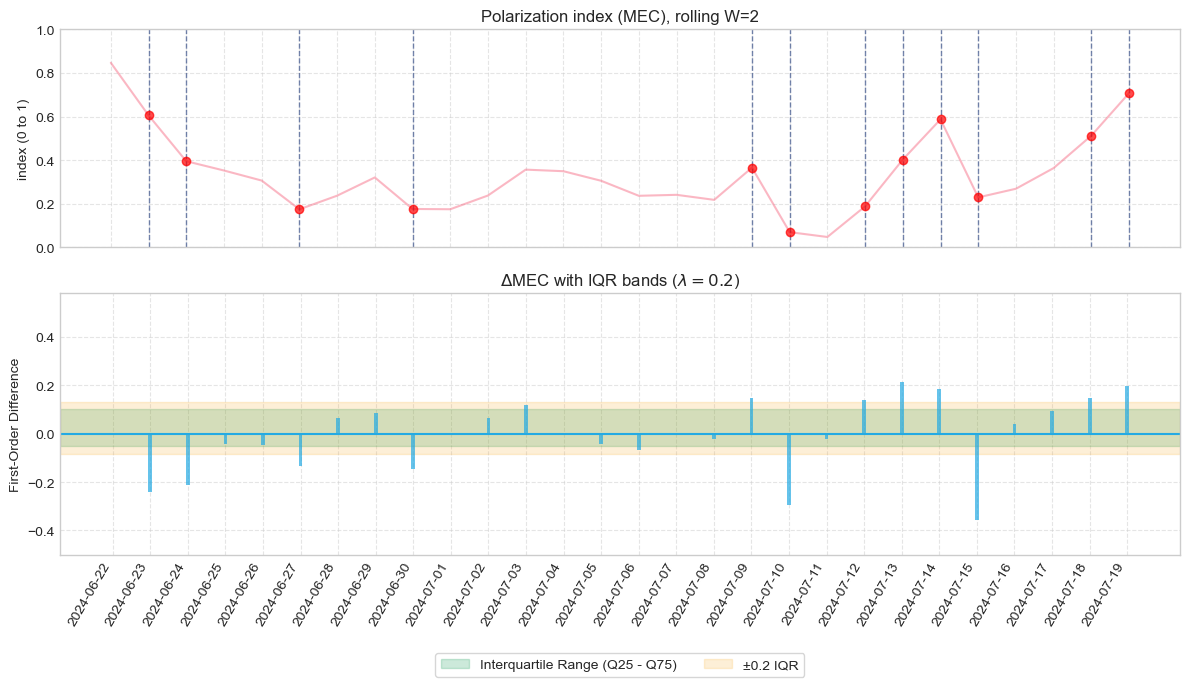

Saved: C:\Users\USUARIO\tareas_maestria\DataExtraction_X\event-detection\article-files\figures\modelo_polarizacion_final.png


In [45]:
serie_key_mec = get_moving_window_key(FINAL["mec"]["W"], False, "all", None)
daily_mec_w2 = opinion_distribution_moving_window[serie_key_mec]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [1, 1.2]})
plot_detected_events(
    daily_mec_w2[["polarization"]],
    [mec_det["date"]],
    window_size=None,
    feature_label="polarization",
    title="Polarization index (MEC), rolling W=2",
    y_label="index (0 to 1)",
    ax=ax1,
    left_margin=0.1,
    is_iqr=True,
    show_xticks=False,
    add_legend=False,
)
plot_polarization_1st_diff_analysis(
    daily_mec_w2["1st_diff_polarization"],
    lambda_val=FINAL["mec"]["lambda"],
    title=r"$\Delta$MEC with IQR bands ($\lambda=0.2$)",
    ax=ax2,
    left_margin=0.1,
)
plt.tight_layout()
fig_path = REPO_ROOT / "figures" / "modelo_polarizacion_final.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", fig_path.resolve())
